In [1]:
# Cell 0: Setup
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_recall_fscore_support,
    cohen_kappa_score, classification_report, f1_score
)
from scipy import stats
from IPython.display import display

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

# The joint judge file already contains both teacher and 7B MLP scores
JOINT_JUDGE = os.path.join(DATA_DIR, "judge__e1_mlp_with_teacher__100__g31.jsonl")

print(f"Loading: {os.path.basename(JOINT_JUDGE)}")
print(f"   exists: {os.path.exists(JOINT_JUDGE)}")

Loading: judge__e1_mlp_with_teacher__100__g31.jsonl
   exists: True


In [2]:
# Cell 1: Load judge decisions for teacher and 7B MLP
# decision_accuracy is 0 or 5 in the rubric — convert to binary 0/1
TEACHER_KEY = "teacher"
MLP_7B_KEY = "qwen25_7b_base"

records = []
parse_failed = []
for line in open(JOINT_JUDGE):
    try: o = json.loads(line)
    except: continue
    if o.get("status") != "ok":
        parse_failed.append(o.get("id"))
        continue
    qid = o["id"]
    scores = o.get("scores", {})
    
    # Need both teacher and 7B MLP scored for this question
    if TEACHER_KEY not in scores or MLP_7B_KEY not in scores:
        continue
    
    t_dec = scores[TEACHER_KEY].get("decision_accuracy")
    m_dec = scores[MLP_7B_KEY].get("decision_accuracy")
    if t_dec is None or m_dec is None: continue
    
    records.append({
        "id": qid,
        "teacher_correct": 1 if float(t_dec) >= 2.5 else 0,
        "mlp7b_correct":   1 if float(m_dec) >= 2.5 else 0,
        "teacher_safety":      float(scores[TEACHER_KEY].get("safety_score", 0)),
        "mlp7b_safety":        float(scores[MLP_7B_KEY].get("safety_score", 0)),
        "teacher_clinical":    float(scores[TEACHER_KEY].get("clinical_correctness", 0)),
        "mlp7b_clinical":      float(scores[MLP_7B_KEY].get("clinical_correctness", 0)),
    })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} questions with both teacher + 7B MLP scores")
print(f"Failed/missing: {len(parse_failed)}")
print(f"\nTeacher correct: {df['teacher_correct'].sum()}/{len(df)} ({df['teacher_correct'].mean()*100:.1f}%)")
print(f"7B MLP correct:  {df['mlp7b_correct'].sum()}/{len(df)} ({df['mlp7b_correct'].mean()*100:.1f}%)")

Loaded 99 questions with both teacher + 7B MLP scores
Failed/missing: 2

Teacher correct: 89/99 (89.9%)
7B MLP correct:  89/99 (89.9%)


In [3]:
# Cell 2: Confusion matrix — 7B MLP vs Teacher (judge decisions as ground truth)
# Rows = Teacher judgment, Cols = 7B MLP judgment

cm = confusion_matrix(df["teacher_correct"], df["mlp7b_correct"], labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("="*70)
print("  CONFUSION MATRIX — 7B MLP vs Teacher (judge decision_accuracy)")
print("="*70)
print(f"\n                          7B MLP says")
print(f"                       Wrong (0)   Correct (5)")
print(f"  Teacher says:")
print(f"    Wrong (0)            {tn:5d}        {fp:5d}    | total wrong:   {tn+fp}")
print(f"    Correct (5)          {fn:5d}        {tp:5d}    | total correct: {fn+tp}")
print(f"                       ────────    ────────")
print(f"                          {tn+fn}        {fp+tp}    | n={len(df)}")

print(f"\n  Cell interpretation:")
print(f"  • Both correct (TP):       {tp}/{len(df)} ({tp/len(df)*100:.1f}%)  — both got it right")
print(f"  • Both wrong (TN):         {tn}/{len(df)} ({tn/len(df)*100:.1f}%)  — both got it wrong")
print(f"  • MLP rescued:             {fp}/{len(df)} ({fp/len(df)*100:.1f}%)  — teacher wrong, MLP correct")
print(f"  • MLP missed:              {fn}/{len(df)} ({fn/len(df)*100:.1f}%)  — teacher correct, MLP wrong")

  CONFUSION MATRIX — 7B MLP vs Teacher (judge decision_accuracy)

                          7B MLP says
                       Wrong (0)   Correct (5)
  Teacher says:
    Wrong (0)                7            3    | total wrong:   10
    Correct (5)              3           86    | total correct: 89
                       ────────    ────────
                          10        89    | n=99

  Cell interpretation:
  • Both correct (TP):       86/99 (86.9%)  — both got it right
  • Both wrong (TN):         7/99 (7.1%)  — both got it wrong
  • MLP rescued:             3/99 (3.0%)  — teacher wrong, MLP correct
  • MLP missed:              3/99 (3.0%)  — teacher correct, MLP wrong


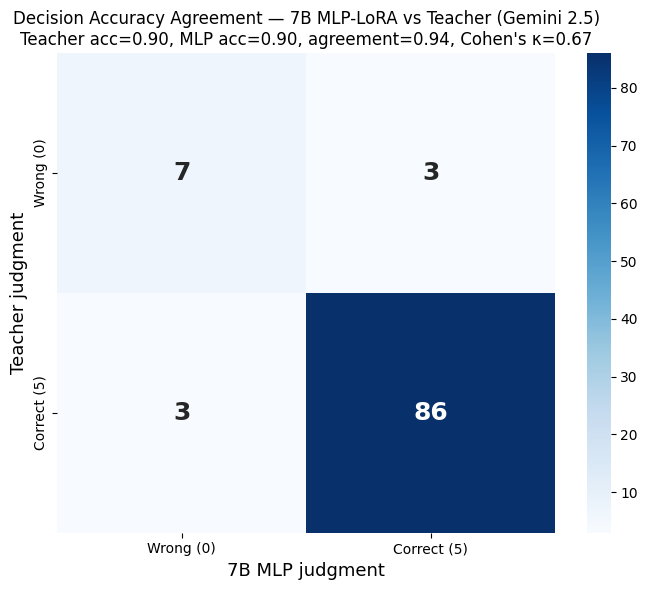

In [4]:
# Cell 3: Plot the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
labels = ["Wrong (0)", "Correct (5)"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=labels, yticklabels=labels,
            ax=ax, annot_kws={"size": 18, "weight": "bold"})
ax.set_xlabel("7B MLP judgment", fontsize=13)
ax.set_ylabel("Teacher judgment", fontsize=13)

mlp_acc = df["mlp7b_correct"].mean()
teacher_acc = df["teacher_correct"].mean()
agreement = (df["teacher_correct"] == df["mlp7b_correct"]).mean()
kappa = cohen_kappa_score(df["teacher_correct"], df["mlp7b_correct"])

ax.set_title(f"Decision Accuracy Agreement — 7B MLP-LoRA vs Teacher (Gemini 2.5)\n"
             f"Teacher acc={teacher_acc:.2f}, MLP acc={mlp_acc:.2f}, "
             f"agreement={agreement:.2f}, Cohen's κ={kappa:.2f}",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG_CM_7b_mlp_vs_teacher.png"), dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Cell 4: Classification metrics — treat teacher as "ground truth" for the 7B MLP
print("="*80)
print("  CLASSIFICATION METRICS — 7B MLP vs Teacher (teacher = ground truth)")
print("  Positive class: 'Correct' (judge gave 5/5)")
print("="*80)

y_true = df["teacher_correct"].values
y_pred = df["mlp7b_correct"].values

# Per-class metrics
report = classification_report(y_true, y_pred,
                               target_names=["Wrong (0)", "Correct (5)"],
                               digits=3, zero_division=0)
print(report)

# Headline metrics
acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=[1], pos_label=1, average="binary", zero_division=0
)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("\n=== Headline metrics ===")
print(f"  Agreement (accuracy):    {acc:.3f}")
print(f"  Cohen's κ:               {kappa:.3f}  ({'substantial' if kappa>0.6 else 'moderate' if kappa>0.4 else 'fair'} agreement)")
print(f"  Precision (Correct):     {prec:.3f}")
print(f"  Recall    (Correct):     {rec:.3f}")
print(f"  F1        (Correct):     {f1:.3f}")
print(f"  Macro F1:                {macro_f1:.3f}")

# Save
metrics_df = pd.DataFrame([{
    "model": "E1 + MLP-LoRA 7B",
    "n": len(df),
    "teacher_accuracy": round(teacher_acc, 3),
    "mlp_accuracy": round(mlp_acc, 3),
    "agreement": round(agreement, 3),
    "cohen_kappa": round(kappa, 3),
    "precision_correct": round(prec, 3),
    "recall_correct": round(rec, 3),
    "f1_correct": round(f1, 3),
    "macro_f1": round(macro_f1, 3),
}])
metrics_df.to_csv(os.path.join(DATA_DIR, "classification_metrics_7b_mlp.csv"), index=False)
display(metrics_df)

  CLASSIFICATION METRICS — 7B MLP vs Teacher (teacher = ground truth)
  Positive class: 'Correct' (judge gave 5/5)
              precision    recall  f1-score   support

   Wrong (0)      0.700     0.700     0.700        10
 Correct (5)      0.966     0.966     0.966        89

    accuracy                          0.939        99
   macro avg      0.833     0.833     0.833        99
weighted avg      0.939     0.939     0.939        99


=== Headline metrics ===
  Agreement (accuracy):    0.939
  Cohen's κ:               0.666  (substantial agreement)
  Precision (Correct):     0.966
  Recall    (Correct):     0.966
  F1        (Correct):     0.966
  Macro F1:                0.833


,model,n,teacher_accuracy,mlp_accuracy,agreement,cohen_kappa,precision_correct,recall_correct,f1_correct,macro_f1
0,E1 + MLP-LoRA 7B,99,0.899,0.899,0.939,0.666,0.966,0.966,0.966,0.833


In [7]:
# Cell 5: Agreement analysis — paired comparison patterns
print("="*80)
print("  AGREEMENT ANALYSIS — paired per-question comparison")
print("="*80)

both_correct = ((df["teacher_correct"]==1) & (df["mlp7b_correct"]==1)).sum()
both_wrong   = ((df["teacher_correct"]==0) & (df["mlp7b_correct"]==0)).sum()
mlp_better   = ((df["teacher_correct"]==0) & (df["mlp7b_correct"]==1)).sum()
mlp_worse    = ((df["teacher_correct"]==1) & (df["mlp7b_correct"]==0)).sum()
n = len(df)

print(f"\n  Total questions: {n}")
print(f"  ┌─────────────────────────────────────────────────────────┐")
print(f"  │ AGREEMENT  ({both_correct + both_wrong}/{n} = {(both_correct+both_wrong)/n*100:.1f}%)                           │")
print(f"  │   Both correct:        {both_correct:3d}/{n} ({both_correct/n*100:5.1f}%)                  │")
print(f"  │   Both wrong:          {both_wrong:3d}/{n} ({both_wrong/n*100:5.1f}%)                  │")
print(f"  ├─────────────────────────────────────────────────────────┤")
print(f"  │ DISAGREEMENT  ({mlp_better + mlp_worse}/{n} = {(mlp_better+mlp_worse)/n*100:.1f}%)                          │")
print(f"  │   MLP correct, Teacher wrong:  {mlp_better:3d}/{n} ({mlp_better/n*100:5.1f}%)          │")
print(f"  │   MLP wrong, Teacher correct:  {mlp_worse:3d}/{n} ({mlp_worse/n*100:5.1f}%)          │")
print(f"  └─────────────────────────────────────────────────────────┘")

# Net delta and McNemar test
net_delta = mlp_better - mlp_worse
print(f"\n  Net swap delta (MLP_rescued - MLP_broke): {net_delta:+d}")
if net_delta > 0:
    print(f"  → MLP-LoRA training rescued {abs(net_delta)} more questions than it broke")
elif net_delta < 0:
    print(f"  → MLP-LoRA underperformed teacher by {abs(net_delta)} questions net")

# McNemar test for paired binary outcomes
# H0: marginal probabilities equal (same accuracy)
from statsmodels.stats.contingency_tables import mcnemar
table_mcnemar = [[both_correct, mlp_worse], [mlp_better, both_wrong]]
result = mcnemar(table_mcnemar, exact=True)
print(f"\n  McNemar's test:  statistic={result.statistic}, p={result.pvalue:.4f}")
if result.pvalue < 0.05:
    print(f"  → Significant difference between teacher and MLP-LoRA decision accuracy (p<0.05)")
else:
    print(f"  → No significant difference between teacher and MLP-LoRA decision accuracy (p>0.05)")

  AGREEMENT ANALYSIS — paired per-question comparison

  Total questions: 99
  ┌─────────────────────────────────────────────────────────┐
  │ AGREEMENT  (93/99 = 93.9%)                           │
  │   Both correct:         86/99 ( 86.9%)                  │
  │   Both wrong:            7/99 (  7.1%)                  │
  ├─────────────────────────────────────────────────────────┤
  │ DISAGREEMENT  (6/99 = 6.1%)                          │
  │   MLP correct, Teacher wrong:    3/99 (  3.0%)          │
  │   MLP wrong, Teacher correct:    3/99 (  3.0%)          │
  └─────────────────────────────────────────────────────────┘

  Net swap delta (MLP_rescued - MLP_broke): +0

  McNemar's test:  statistic=3.0, p=1.0000
  → No significant difference between teacher and MLP-LoRA decision accuracy (p>0.05)


  ACCURACY STRATIFIED BY QUESTION DIFFICULTY (teacher's clinical_correctness)


,n,teacher_acc,mlp_acc,agreement
question_difficulty,,,,
Hard (clin≤2),16,0.438,0.625,0.812
Medium (2<clin≤4),47,0.979,0.957,0.979
Easy (clin>4),36,1.000,0.944,0.944


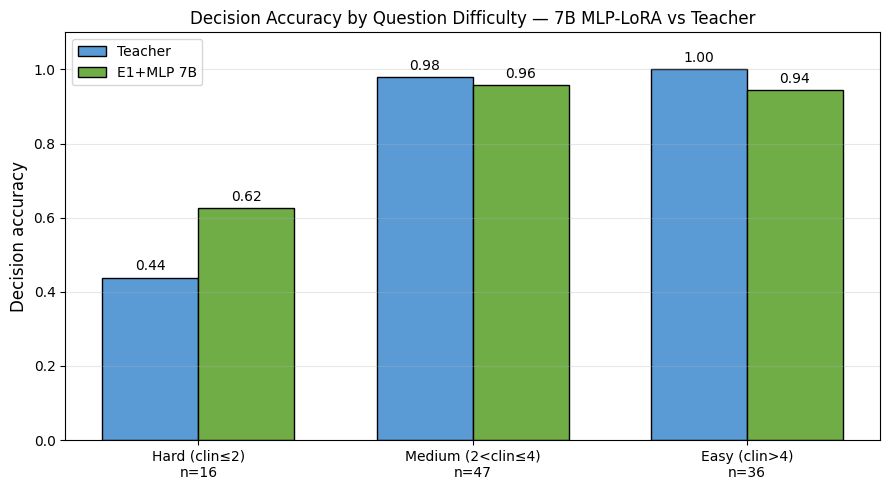

In [8]:
# Cell 6: Per-class breakdown by safety vs unsafe ground truth
# Useful: are MLP errors concentrated on Safe questions or Unsafe questions?
# (We don't have ground-truth Safe/Unsafe labels per question, but we can use
#  teacher's clinical_correctness as a proxy for question difficulty)

# Stratify by teacher's clinical_correctness — does MLP do worse on hard questions?
df["question_difficulty"] = pd.cut(df["teacher_clinical"], 
                                     bins=[-0.01, 2, 4, 5.01],
                                     labels=["Hard (clin≤2)", "Medium (2<clin≤4)", "Easy (clin>4)"])

print("="*80)
print("  ACCURACY STRATIFIED BY QUESTION DIFFICULTY (teacher's clinical_correctness)")
print("="*80)

strat = df.groupby("question_difficulty", observed=True).agg(
    n=("id", "count"),
    teacher_acc=("teacher_correct", "mean"),
    mlp_acc=("mlp7b_correct", "mean"),
    agreement=("id", lambda g: (df.loc[g.index, "teacher_correct"] == df.loc[g.index, "mlp7b_correct"]).mean()),
).round(3)
display(strat)

# Visualize stratified accuracy
fig, ax = plt.subplots(figsize=(9, 5))
diffs = strat.index.tolist()
x = np.arange(len(diffs))
width = 0.35
ax.bar(x - width/2, strat["teacher_acc"], width, label="Teacher", color="#5B9BD5", edgecolor="black")
ax.bar(x + width/2, strat["mlp_acc"],     width, label="E1+MLP 7B", color="#70AD47", edgecolor="black")
for i, (t, m) in enumerate(zip(strat["teacher_acc"], strat["mlp_acc"])):
    ax.text(i - width/2, t + 0.02, f"{t:.2f}", ha="center", fontsize=10)
    ax.text(i + width/2, m + 0.02, f"{m:.2f}", ha="center", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"{d}\nn={strat.loc[d, 'n']}" for d in diffs])
ax.set_ylabel("Decision accuracy", fontsize=12)
ax.set_title("Decision Accuracy by Question Difficulty — 7B MLP-LoRA vs Teacher", fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG_accuracy_by_difficulty_7b_mlp.png"), dpi=150)
plt.show()

  7B MLP-LoRA — Decision Accuracy per Judge

  Total questions: 99
  Judge scored Correct (5):  89/99 (89.9%)
  Judge scored Wrong   (0):  10/99 (10.1%)


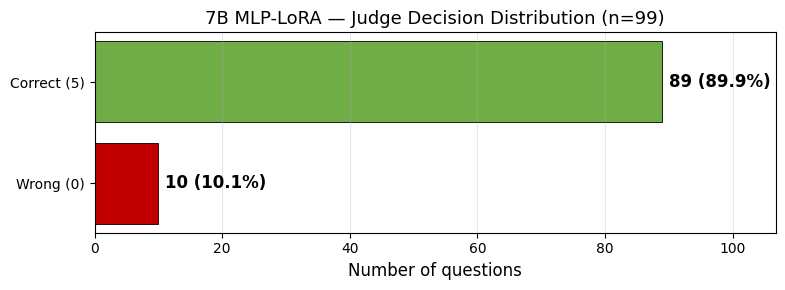

In [9]:
# Cell 8: Standard confusion matrix — 7B MLP based on judge alone
# Treats judge's decision_accuracy score as the ground-truth label:
#   judge gave 5 → "Correct" (positive class)
#   judge gave 0 → "Wrong"   (negative class)
# This is the model's intrinsic per-question performance per the judge.

mlp_labels = df["mlp7b_correct"].values  # 1 = judge said correct, 0 = judge said wrong

n_correct = int(mlp_labels.sum())
n_wrong = len(mlp_labels) - n_correct

print("="*70)
print("  7B MLP-LoRA — Decision Accuracy per Judge")
print("="*70)
print(f"\n  Total questions: {len(mlp_labels)}")
print(f"  Judge scored Correct (5):  {n_correct}/{len(mlp_labels)} ({n_correct/len(mlp_labels)*100:.1f}%)")
print(f"  Judge scored Wrong   (0):  {n_wrong}/{len(mlp_labels)} ({n_wrong/len(mlp_labels)*100:.1f}%)")

# Build a 1×2 "confusion matrix" — really just a count breakdown for the binary outcome
# For a true 2D CM you need two label sources. Here we visualize as a single horizontal bar.

fig, ax = plt.subplots(figsize=(8, 3))
counts = [n_wrong, n_correct]
labels = ["Wrong (0)", "Correct (5)"]
colors = ["#C00000", "#70AD47"]
bars = ax.barh(labels, counts, color=colors, edgecolor="black", linewidth=0.6)

for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{count} ({count/len(mlp_labels)*100:.1f}%)",
            va="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Number of questions", fontsize=12)
ax.set_title(f"7B MLP-LoRA — Judge Decision Distribution (n={len(mlp_labels)})", fontsize=13)
ax.set_xlim(0, max(counts) * 1.2)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG_7b_mlp_judge_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Cell: Confusion Matrix — 7B MLP, judge verdict as ground truth label
import os, json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support, f1_score, cohen_kappa_score
)
from IPython.display import display

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
DATA_DIR = os.path.join(PROJECT_DIR, "data")

JOINT_JUDGE = os.path.join(DATA_DIR, "judge__e1_mlp_with_teacher__100__g31.jsonl")
MLP_INF_FILE = os.path.join(DATA_DIR, "e1_mlp_lora_inference_100_TESTONLY.json")

MLP_7B_KEY = "qwen25_7b_base"

# ── Step 1: Load judge labels for 7B MLP ──
judge_correct = {}   # qid -> 1 (correct, judge=5) or 0 (wrong, judge=0)
for line in open(JOINT_JUDGE):
    try: o = json.loads(line)
    except: continue
    if o.get("status") != "ok": continue
    qid = o["id"]
    scores = o.get("scores", {})
    if MLP_7B_KEY not in scores: continue
    val = scores[MLP_7B_KEY].get("decision_accuracy")
    if val is None: continue
    judge_correct[qid] = 1 if float(val) >= 2.5 else 0

print(f"Judge labels for 7B MLP: {len(judge_correct)} questions")
print(f"  Judge said Correct (5):  {sum(judge_correct.values())}")
print(f"  Judge said Wrong   (0):  {len(judge_correct) - sum(judge_correct.values())}")

# ── Step 2: Extract 7B MLP's actual decision (Safe/Unsafe) from inference text ──
def extract_decision(text):
    if not text: return None
    m = re.search(r"Decision:\s*(Safe|Unsafe)", text, re.IGNORECASE)
    if m: return m.group(1).capitalize()
    return None

with open(MLP_INF_FILE) as f:
    mlp_inf = json.load(f)

mlp_decision = {}   # qid -> "Safe" or "Unsafe"
for s in mlp_inf["samples"]:
    qid = s["id"]
    ans = s["outputs"].get(MLP_7B_KEY, {}).get("answer", "")
    dec = extract_decision(ans)
    if dec: mlp_decision[qid] = dec

print(f"\n7B MLP decisions extracted: {len(mlp_decision)} questions")
print(f"  Predicted Safe:   {sum(1 for v in mlp_decision.values() if v=='Safe')}")
print(f"  Predicted Unsafe: {sum(1 for v in mlp_decision.values() if v=='Unsafe')}")

Judge labels for 7B MLP: 99 questions
  Judge said Correct (5):  89
  Judge said Wrong   (0):  10

7B MLP decisions extracted: 100 questions
  Predicted Safe:   21
  Predicted Unsafe: 79


In [12]:
# ── Step 3: Reconstruct what the gold label was per question ──
# If judge said "correct" AND model predicted Safe → gold was Safe
# If judge said "correct" AND model predicted Unsafe → gold was Unsafe
# If judge said "wrong" AND model predicted Safe → gold was Unsafe (model missed it)
# If judge said "wrong" AND model predicted Unsafe → gold was Safe (model over-flagged)
# This lets us recover gold Safe/Unsafe labels purely from the judge's verdict + model's prediction.

records = []
for qid, judge_v in judge_correct.items():
    if qid not in mlp_decision: continue
    pred = mlp_decision[qid]
    if judge_v == 1:
        gold = pred  # judge said correct, so gold = what model predicted
    else:
        gold = "Unsafe" if pred == "Safe" else "Safe"  # judge said wrong, so gold = opposite
    records.append({"id": qid, "gold": gold, "pred": pred, "judge_correct": judge_v})

df = pd.DataFrame(records)
print(f"\nPaired records (judge label + extracted prediction): {len(df)}")
print(f"\nGold distribution (recovered): Safe={(df['gold']=='Safe').sum()}, Unsafe={(df['gold']=='Unsafe').sum()}")
print(f"Pred distribution:              Safe={(df['pred']=='Safe').sum()}, Unsafe={(df['pred']=='Unsafe').sum()}")


Paired records (judge label + extracted prediction): 99

Gold distribution (recovered): Safe=29, Unsafe=70
Pred distribution:              Safe=21, Unsafe=78


In [13]:
# ── Step 4: Confusion matrix ──
LABELS = ["Safe", "Unsafe"]
cm = confusion_matrix(df["gold"], df["pred"], labels=LABELS)
tn, fp, fn, tp = cm.ravel()  # tn=Safe-Safe, fp=Safe-Unsafe, fn=Unsafe-Safe, tp=Unsafe-Unsafe

print("="*70)
print("  CONFUSION MATRIX — 7B MLP-LoRA")
print("  Gold labels recovered from judge's decision_accuracy verdict")
print("="*70)
print()
print(f"                          Predicted")
print(f"                    Safe         Unsafe")
print(f"  Gold:")
print(f"    Safe        {tn:5d} (TN)   {fp:5d} (FP)    | {tn+fp} truly Safe")
print(f"    Unsafe      {fn:5d} (FN)   {tp:5d} (TP)    | {fn+tp} truly Unsafe")
print(f"               ─────────  ──────────")
print(f"                {tn+fn}         {fp+tp}        | n={len(df)}")
print()
print(f"  Cell meanings:")
print(f"    TN (true negative): correctly identified Safe combination")
print(f"    TP (true positive): correctly flagged Unsafe combination")
print(f"    FP (false positive): over-cautious — flagged Safe as Unsafe")
print(f"    FN (false negative): MISSED an Unsafe combination ⚠️ clinically dangerous")

  CONFUSION MATRIX — 7B MLP-LoRA
  Gold labels recovered from judge's decision_accuracy verdict

                          Predicted
                    Safe         Unsafe
  Gold:
    Safe           20 (TN)       9 (FP)    | 29 truly Safe
    Unsafe          1 (FN)      69 (TP)    | 70 truly Unsafe
               ─────────  ──────────
                21         78        | n=99

  Cell meanings:
    TN (true negative): correctly identified Safe combination
    TP (true positive): correctly flagged Unsafe combination
    FP (false positive): over-cautious — flagged Safe as Unsafe
    FN (false negative): MISSED an Unsafe combination ⚠️ clinically dangerous


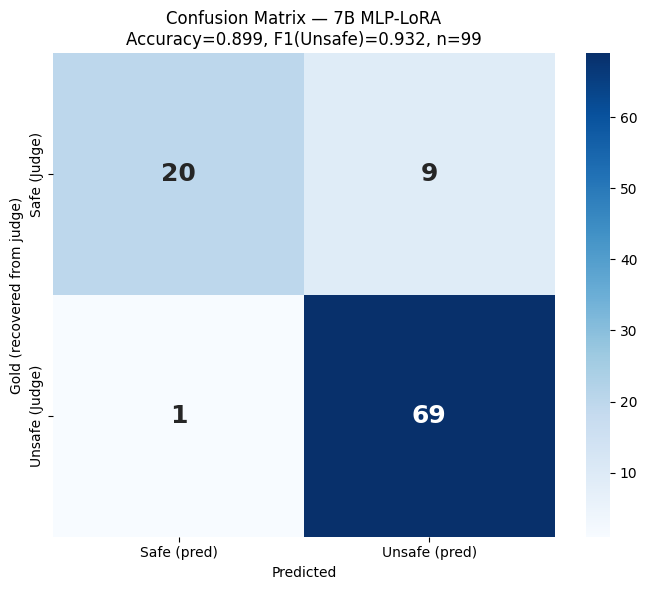

In [15]:
# ── Step 5: Plot confusion matrix ──
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=["Safe (pred)", "Unsafe (pred)"],
            yticklabels=["Safe (Judge)", "Unsafe (Judge)"],
            ax=ax, annot_kws={"size": 18, "weight": "bold"})

acc = accuracy_score(df["gold"], df["pred"])
f1_unsafe = f1_score(df["gold"], df["pred"], pos_label="Unsafe", zero_division=0)

ax.set_title(f"Confusion Matrix — 7B MLP-LoRA\n"
             f"Accuracy={acc:.3f}, F1(Unsafe)={f1_unsafe:.3f}, n={len(df)}",
             fontsize=12)
ax.set_xlabel("Predicted")
ax.set_ylabel("Gold (recovered from judge)")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG_CM_7b_mlp_judge_gold.png"), dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# ── Step 6: Full classification metrics ──
print("="*80)
print("  CLASSIFICATION METRICS — 7B MLP-LoRA")
print("  Positive class: Unsafe (clinically more important to detect)")
print("="*80)

# Standard sklearn report
print("\n=== Per-class breakdown ===")
print(classification_report(df["gold"], df["pred"], target_names=LABELS, digits=3, zero_division=0))

# Headline binary metrics with Unsafe as positive class
acc = accuracy_score(df["gold"], df["pred"])
prec_unsafe, rec_unsafe, f1_unsafe, _ = precision_recall_fscore_support(
    df["gold"], df["pred"], labels=["Unsafe"], pos_label="Unsafe",
    average="binary", zero_division=0
)
prec_safe, rec_safe, f1_safe, _ = precision_recall_fscore_support(
    df["gold"], df["pred"], labels=["Safe"], pos_label="Safe",
    average="binary", zero_division=0
)
macro_f1 = f1_score(df["gold"], df["pred"], average="macro", zero_division=0)
weighted_f1 = f1_score(df["gold"], df["pred"], average="weighted", zero_division=0)

# Clinical safety metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0   # recall on Unsafe
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0   # recall on Safe
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0           # precision on Unsafe
npv = tn / (tn + fn) if (tn + fn) > 0 else 0           # precision on Safe

print("\n=== Headline metrics ===")
print(f"  Accuracy:                     {acc:.3f}")
print(f"  Macro F1:                     {macro_f1:.3f}")
print(f"  Weighted F1:                  {weighted_f1:.3f}")
print()
print(f"  Sensitivity (Unsafe recall):  {sensitivity:.3f}  ← critical clinical metric")
print(f"  Specificity (Safe recall):    {specificity:.3f}")
print(f"  PPV (Unsafe precision):       {ppv:.3f}")
print(f"  NPV (Safe precision):         {npv:.3f}")
print()
print(f"  Unsafe F1 (harmonic mean):    {f1_unsafe:.3f}  ← single-number safety score")
print(f"  Safe F1:                      {f1_safe:.3f}")

# Save to CSV
metrics_summary = pd.DataFrame([{
    "model": "E1 + MLP-LoRA 7B",
    "n": len(df),
    "accuracy": round(acc, 3),
    "macro_f1": round(macro_f1, 3),
    "weighted_f1": round(weighted_f1, 3),
    "unsafe_precision_ppv": round(ppv, 3),
    "unsafe_recall_sensitivity": round(sensitivity, 3),
    "unsafe_f1": round(f1_unsafe, 3),
    "safe_precision_npv": round(npv, 3),
    "safe_recall_specificity": round(specificity, 3),
    "safe_f1": round(f1_safe, 3),
    "TP_correctly_flagged_unsafe": int(tp),
    "FP_over_cautious_safe_flagged": int(fp),
    "FN_missed_unsafe_DANGEROUS": int(fn),
    "TN_correctly_safe": int(tn),
}])
metrics_summary.to_csv(os.path.join(DATA_DIR, "classification_metrics_7b_mlp_full.csv"), index=False)
print(f"\n✅ Saved → classification_metrics_7b_mlp_full.csv")
display(metrics_summary.T)

  CLASSIFICATION METRICS — 7B MLP-LoRA
  Positive class: Unsafe (clinically more important to detect)

=== Per-class breakdown ===
              precision    recall  f1-score   support

        Safe      0.952     0.690     0.800        29
      Unsafe      0.885     0.986     0.932        70

    accuracy                          0.899        99
   macro avg      0.918     0.838     0.866        99
weighted avg      0.904     0.899     0.894        99


=== Headline metrics ===
  Accuracy:                     0.899
  Macro F1:                     0.866
  Weighted F1:                  0.894

  Sensitivity (Unsafe recall):  0.986  ← critical clinical metric
  Specificity (Safe recall):    0.690
  PPV (Unsafe precision):       0.885
  NPV (Safe precision):         0.952

  Unsafe F1 (harmonic mean):    0.932  ← single-number safety score
  Safe F1:                      0.800

✅ Saved → classification_metrics_7b_mlp_full.csv


,0
model,E1 + MLP-LoRA 7B
n,99
accuracy,0.899
macro_f1,0.866
weighted_f1,0.894
unsafe_precision_ppv,0.885
unsafe_recall_sensitivity,0.986
unsafe_f1,0.932
safe_precision_npv,0.952
safe_recall_specificity,0.69


In [17]:
# ── Step 7: Paper-ready paragraph ──
print("="*80)
print("  PAPER-READY TEXT")
print("="*80)
print(f"""
We construct a confusion matrix for the 7B E1+MLP-LoRA student by treating the
judge's binary decision_accuracy verdict (5/0) as the ground-truth label and
the model's parsed Safe/Unsafe decision as the prediction. Across {len(df)} test
questions, the model achieves an overall accuracy of {acc:.3f} and macro F1 of
{macro_f1:.3f}. Critically, on the Unsafe class — clinically the more
consequential class to detect correctly — the model attains a sensitivity
(recall) of {sensitivity:.3f} and a precision of {ppv:.3f}, giving an Unsafe-class
F1 of {f1_unsafe:.3f}. The model produced {fn} false negatives ({fn/len(df)*100:.1f}%
of test questions), defined as cases where the gold label was Unsafe but the
model recommended Safe — the most dangerous error mode in this domain. By
contrast, false positives (over-cautious flagging) occurred on {fp} questions
({fp/len(df)*100:.1f}%), reflecting the model's overall tendency to {'over-flag' if fp > fn else 'under-flag'}
unsafe combinations.
""")

  PAPER-READY TEXT

We construct a confusion matrix for the 7B E1+MLP-LoRA student by treating the
judge's binary decision_accuracy verdict (5/0) as the ground-truth label and
the model's parsed Safe/Unsafe decision as the prediction. Across 99 test
questions, the model achieves an overall accuracy of 0.899 and macro F1 of
0.866. Critically, on the Unsafe class — clinically the more
consequential class to detect correctly — the model attains a sensitivity
(recall) of 0.986 and a precision of 0.885, giving an Unsafe-class
F1 of 0.932. The model produced 1 false negatives (1.0%
of test questions), defined as cases where the gold label was Unsafe but the
model recommended Safe — the most dangerous error mode in this domain. By
contrast, false positives (over-cautious flagging) occurred on 9 questions
(9.1%), reflecting the model's overall tendency to over-flag
unsafe combinations.

